## Figure 2 - Behavioral performance across experience

This script generates Figure 2, showing behavior metrics
across experience levels (Familiar, Novel, Novel+) including d-prime, hit rate,
response latency, running speed, pupil diameter, and lick rate.

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.utilities as vbu
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_2')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [25]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
platform_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_behavior_sessions_table.csv'), index_col=0)
platform_ophys_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_ophys_behavior_sessions_table.csv'), index_col=0)

# save to more convenient name
behavior_sessions = platform_behavior_sessions.copy()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

In [26]:
print(len(behavior_sessions.mouse_id.unique()), 'mice')
print(len(behavior_sessions.index.unique()), 'behavior sessions')


66 mice
2942 behavior sessions


In [27]:
print(len(platform_ophys_behavior_sessions.mouse_id.unique()), 'mice')
print(len(platform_ophys_behavior_sessions.ophys_experiment_id.unique()), 'experiments')
print(len(platform_ophys_behavior_sessions.ophys_session_id.unique()), 'ophys sessions')
print(len(platform_ophys_behavior_sessions.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


### Stimulus-based behavior data (loaded and quantified once)

Single source of truth for auto-reward handling: the **full** record keeps the auto-rewarded warm-up (running speed / pupil), `sbr_trim` drops it via `vbu.drop_autorewarded_warmup` (all task-performance metrics). Everything below uses these objects.

In [28]:
# ===== Stimulus-based behavior data: load once, quantify once =====
#   stim_behavior_response_df : FULL record (auto-rewarded warm-up KEPT)  -> running speed & pupil
#   sbr_trim                  : warm-up DROPPED (vbu.drop_autorewarded_warmup) -> task-performance metrics
stim_behavior_response_df, problem_mice = loading.get_stimulus_behavior_response_df(
    platform_experiments.mouse_id.unique(), metadata_table=platform_experiments)
print(len(stim_behavior_response_df.mouse_id.unique()), 'mice loaded; problem mice:', problem_mice)

sbr_trim = vbu.drop_autorewarded_warmup(stim_behavior_response_df)
session_meta = (platform_experiments[['behavior_session_id', 'mouse_id', 'experience_level', 'cell_type']]
                .drop_duplicates('behavior_session_id'))

# rolling performance over the session, across mice (task metrics -> trimmed df)
rolling_mouse = (vbu.get_stimulus_based_rolling_performance_df_for_dataset(
        sbr_trim, session_key='behavior_session_id', response_col='licked')
    .merge(session_meta[['behavior_session_id', 'mouse_id', 'experience_level']], on='behavior_session_id', how='left'))

# session-level stimulus-based stats (full session + engaged), task metrics from the trimmed df
def _opp(sp):
    go = sp[(sp.auto_rewarded == False) & (sp.could_change == True) & (sp.is_change == True)]
    catch = sp[(sp.auto_rewarded == False) & (sp.could_change == True) & (sp.is_change == False)]
    hits = go[go['licked'].astype(bool)]
    return pd.Series({
        'hit_rate': go['licked'].mean(),
        'fa_rate': catch['licked'].mean(),
        'dprime': vbu.dprime(go_trials=go['licked'], catch_trials=catch['licked'], limits=True),
        'lick_latency': hits['lick_latency'].astype(float).mean() if 'lick_latency' in sp.columns else np.nan,
    })
def _sess(sp):
    whole = _opp(sp)
    eng = _opp(sp[sp.engagement_state == 'engaged']).add_suffix('_engaged')
    opps = sp[(sp.auto_rewarded == False) & (sp.could_change == True)]
    frac = pd.Series({'fraction_engaged': (opps['engagement_state'] == 'engaged').mean()})
    return pd.concat([whole, eng, frac])
def _roll(roll):
    eng = roll.loc[roll['engagement_state'] == 'engaged', 'rolling_dprime']
    return pd.Series({'mean_dprime': roll['rolling_dprime'].mean(), 'max_dprime': roll['rolling_dprime'].max(),
                      'mean_dprime_engaged': eng.mean(), 'max_dprime_engaged': eng.max()})
stim_stats = (sbr_trim.groupby('behavior_session_id').apply(_sess)
              .join(rolling_mouse.groupby('behavior_session_id').apply(_roll))
              .reset_index().merge(session_meta, on='behavior_session_id', how='left'))

# response rate by flash type (task metric; carries fraction_engaged for the >=50%-engaged filter)
def _first(df, names):
    return next((n for n in names if n in df.columns), None)
flash_types = [('change', _first(sbr_trim, ['is_change'])),
               ('could_change', _first(sbr_trim, ['could_change'])),
               ('omission', _first(sbr_trim, ['omitted', 'is_omitted'])),
               ('post-omission', _first(sbr_trim, ['post_omitted', 'post_omission']))]
_rr = []
for lab, col in flash_types:
    if col is None:
        continue
    g = (sbr_trim[sbr_trim[col] == True].groupby('behavior_session_id')['licked']
         .mean().rename('response_rate').reset_index())
    g['trial_type'] = lab
    _rr.append(g)
response_rate_df = pd.concat(_rr, ignore_index=True).merge(
    stim_stats[['behavior_session_id', 'experience_level', 'mouse_id', 'fraction_engaged']],
    on='behavior_session_id', how='left')

# running / pupil over first minutes of session: KEEP the warm-up -> build from the FULL df
image_sdf = stim_behavior_response_df.reset_index()
image_sdf = image_sdf[(image_sdf.is_change == False) & (image_sdf.omitted == False)]
image_sdf['mean_pupil_width'] = (image_sdf['mean_pupil_width'] - 1) * 100   # % of baseline
image_sdf['stimulus_number'] = image_sdf.groupby(['mouse_id', 'behavior_session_id']).cumcount() + 1

print('stim_stats:', stim_stats.shape, '| rolling_mouse:', rolling_mouse.shape,
      '| response_rate_df:', response_rate_df.shape)


66 mice loaded; problem mice: []


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))


stim_stats: (202, 17) | rolling_mouse: (201466, 20) | response_rate_df: (808, 6)


### Multi-session dataframes for behavior variables

In [29]:
# # Set params
# interpolate = False
# output_sampling_rate = 30
# inclusion_criteria = 'platform_experiment_table'

# # Running speed
# event_type = 'all'
# data_type = 'running_speed'
# conditions = ['ophys_experiment_id', 'is_change']
# running_speed_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria,
#                                                                interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                epoch_duration_mins=None)
# running_speed_mdf_changes = running_speed_mdf[running_speed_mdf.is_change == True]
# running_speed_mdf_changes = running_speed_mdf_changes.drop_duplicates(subset='behavior_session_id')

# # Running speed - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# running_speed_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                        epoch_duration_mins=5)
# running_speed_mdf_changes_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == True]
# running_speed_mdf_images_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == False]

# # Pupil diameter
# data_type = 'pupil_width'
# conditions = ['ophys_experiment_id', 'is_change']
# full_pupil_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                             interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                             epoch_duration_mins=None)
# pupil_mdf = full_pupil_mdf[full_pupil_mdf.is_change == True]
# pupil_mdf = pupil_mdf.drop_duplicates(subset='behavior_session_id')
# pupil_mdf = pupil_mdf[pupil_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Pupil diameter - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# pupil_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                               interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                               epoch_duration_mins=5)
# pupil_mdf_changes_epochs = pupil_mdf_epochs[pupil_mdf_epochs.is_change == True]

# # Lick rate
# data_type = 'lick_rate'
# conditions = ['ophys_experiment_id', 'is_change']
# lick_rate_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                            interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                            epoch_duration_mins=None)
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.is_change == True]
# lick_rate_mdf = lick_rate_mdf.drop_duplicates(subset='behavior_session_id')
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Lick rate - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# lick_rate_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                   interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                   epoch_duration_mins=5)
# lick_rate_mdf_changes_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == True]
# lick_rate_mdf_images_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == False]

### Behavior metrics

## Plotting

### Panel A: Lick raster for Familiar/Novel/Novel+ comparison
Select example mouse with data at all experience levels

In [30]:
mouse_id = 425496

# Get datasets for each experience level
familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id == mouse_id) &
                                             (platform_experiments.experience_level == 'Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

novel_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel') &
                                         (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

novel_plus_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel +') &
                                              (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_plus_dataset = loading.get_ophys_dataset(novel_plus_experiment_id)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

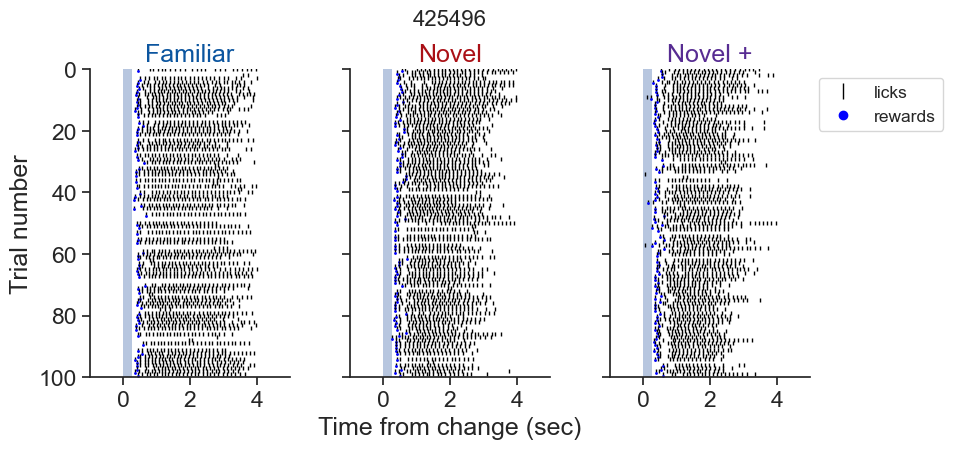

In [31]:

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', legend=True, ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

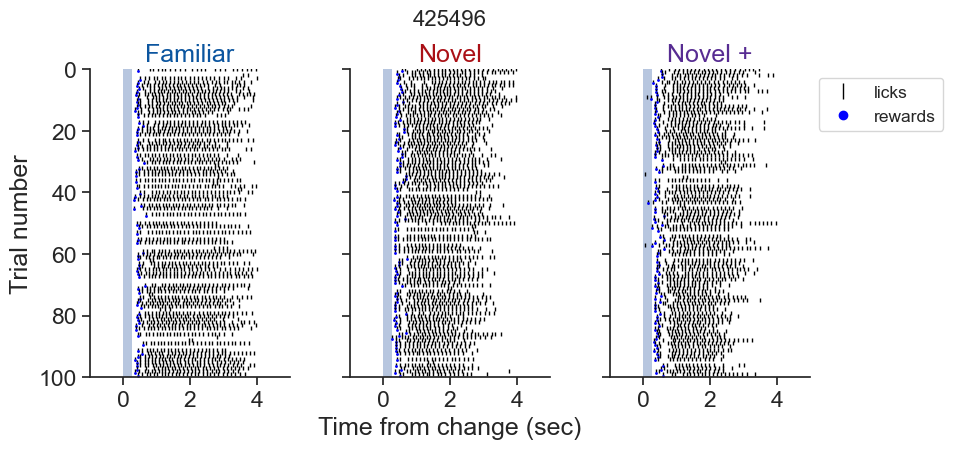

In [32]:

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', legend=True, ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

### Behavior performance

<Axes: ylabel='Max d-prime'>

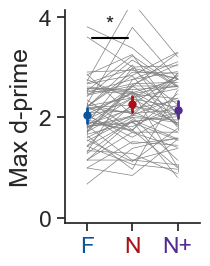

In [33]:
metric = 'max_dprime'
stats = stim_stats.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Max d-prime', ylims=[-0.1, 3.5],
                                      best_image=False, show_mice=True, plot_stats=True,
                                      stripplot=False, show_ns=False, 
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

<Axes: ylabel='Response latency (s)'>

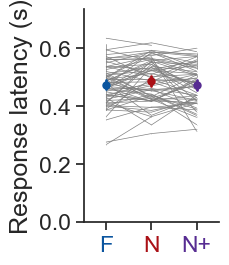

In [34]:
metric = 'lick_latency'
stats = stim_stats.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Response latency (s)', 
                                    ylims=None, show_mice=True, plot_stats=True, stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

### Event aligned behavior

#### Load dataframes for running, pupil, and licks, for both changes & omissions

In [35]:
#### Multi-session dataframes for behavior variables

epoch_duration_mins = None

# Running speed
running_speed_mdf_changes = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Pupil diameter
pupil_mdf_changes = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_platform_experiment_table.feather
there are 1880 experiments in the full multi_session_df
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table
1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_pupil_width_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather fil

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2457: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2457: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


<Axes: ylabel='Pupil diameter (%)'>

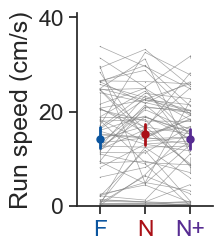

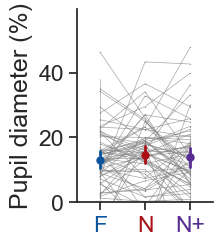

In [36]:
title = ''
#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='Run speed (cm/s)', ylims=None, show_mice=True, save_dir=save_dir, folder='behavior_metrics',
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=None)


#### Pupil 

#### Changes

df = pupil_mdf_changes.copy()
df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='Pupil diameter (%)', ylims=None, show_mice=True, save_dir=save_dir, folder='behavior_metrics',
                                            pointplot=True, stripplot=False, horiz=False, title=title, ax=None)




### Within session changes in behavior

##### Rolling d-prime using false alarm rate across stimulus presentations

In [37]:
import visual_behavior.utilities as utilities

In [38]:
stim_behavior_response_df.head()

,stimulus_presentations_id,start_time,is_change,could_change,is_sham_change,auto_rewarded,omitted,post_omitted,image_name,is_image_novel,...,response_latency,lick_latency,licked,reward_rate,engaged,engagement_state,behavior_session_id,mouse_id,experience_level,cell_type
0,1,307.176084,False,False,False,False,False,False,im065,False,...,0.595966,0.595966,True,1.221875,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
1,2,307.926674,False,False,False,False,False,False,im065,False,...,0.012176,0.012176,True,1.225356,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
2,3,308.677274,False,False,False,False,False,False,im065,False,...,NaN,NaN,False,1.228846,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
3,4,309.427924,False,False,False,False,False,False,im065,False,...,NaN,NaN,False,1.235358,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
4,5,310.178494,False,False,False,False,False,False,im065,False,...,NaN,NaN,False,1.244789,False,disengaged,794968300,412036,Familiar,Vip Inhibitory


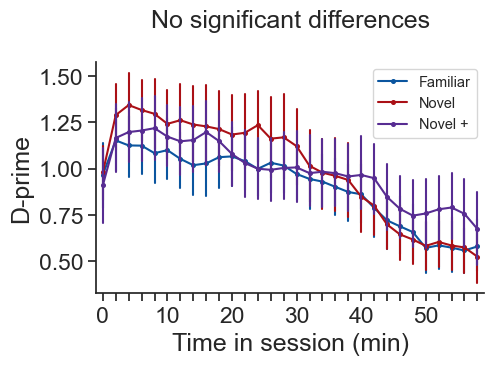

In [39]:
# rolling d-prime over time in session, in 2 min bins, x labeled in 10 min increments
# add_stats=True runs the per-bin across-experience-level stats INSIDE the plot, using the
# same binning as the plot (so they can never drift): MLM with random intercept per mouse,
# BH-FDR across bins; contiguous significant bins -> spanning line, isolated -> star.
# plot_ns=True labels the panel 'No significant differences' if nothing survives correction.
ax = ppf.plot_rolling_metric_over_time_in_session(
    rolling_mouse, metric='rolling_dprime',
    bin_size_seconds=120, max_minutes=60, label_every=5,
    ylabel="D-prime", add_stats=True, plot_ns=True,
    save_dir=save_dir, folder='within_session_behavior',
)

##### Mean d-prime in 15-minute bins, distribution across mice by experience level

`ppf.plot_metric_in_time_bins_by_experience` supports `plot_type='boxplot'` (boxes across mice + gray per-mouse lines) or `plot_type='pointplot'` (mean ± CI across mice, connected across time bins).

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3087: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['%d-%d' % (int(b), int(b) + bin_size_minutes) for b in bin_order])


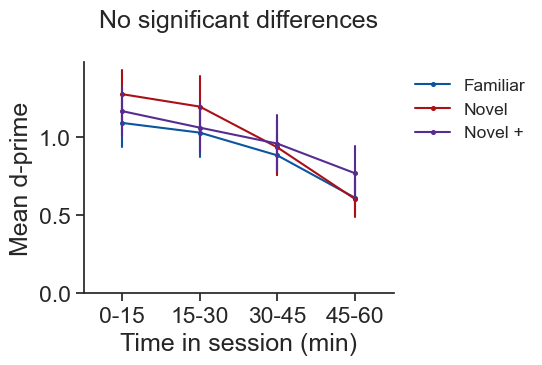

In [40]:
# Same data, plotted as a pointplot: mean +/- CI across mice, connected across time bins.
# add_stats=True -> per-bin across-experience stats using this function's 15 min bins (always
# linked to the plot's binning); filename/CSV also derive from bin_size_minutes automatically.
ax = ppf.plot_metric_in_time_bins_by_experience(
    rolling_mouse, metric='rolling_dprime', bin_size_minutes=15, max_minutes=60,
    plot_type='pointplot', ylabel='Mean d-prime',
    add_stats=True, plot_ns=True, save_dir=save_dir)

##### Pupil diameter in first 2 mins of session

##### New version of stim behavior response df

In [41]:
stim_behavior_response_df.head()

,stimulus_presentations_id,start_time,is_change,could_change,is_sham_change,auto_rewarded,omitted,post_omitted,image_name,is_image_novel,...,response_latency,lick_latency,licked,reward_rate,engaged,engagement_state,behavior_session_id,mouse_id,experience_level,cell_type
0,1,307.176084,False,False,False,False,False,False,im065,False,...,0.595966,0.595966,True,1.221875,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
1,2,307.926674,False,False,False,False,False,False,im065,False,...,0.012176,0.012176,True,1.225356,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
2,3,308.677274,False,False,False,False,False,False,im065,False,...,NaN,NaN,False,1.228846,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
3,4,309.427924,False,False,False,False,False,False,im065,False,...,NaN,NaN,False,1.235358,False,disengaged,794968300,412036,Familiar,Vip Inhibitory
4,5,310.178494,False,False,False,False,False,False,im065,False,...,NaN,NaN,False,1.244789,False,disengaged,794968300,412036,Familiar,Vip Inhibitory


<Axes: title={'center': 'Pupil diameter over first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Pupil diameter (%)'>

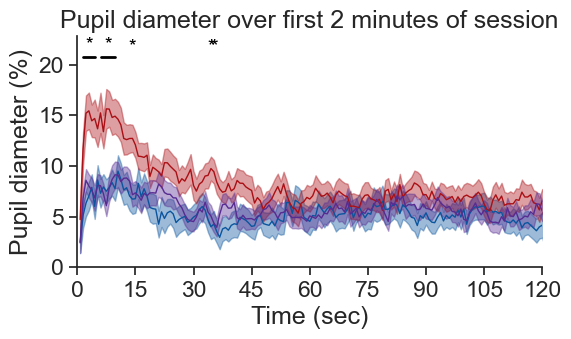

In [42]:
# pupil diameter over first 2 min of session (image_sdf is built in the stimulus-based prep cell at the top)
metric = 'mean_pupil_width'
ylabel = 'Pupil diameter (%)'
time_window_min = 2
ylim = (0, 20)
title = f'Pupil diameter over first {time_window_min} minutes of session'

# add_stats=True -> per-stimulus across-experience stats over the same window the plot shows
# (x = stimulus_presentations_id). ~160 stimuli -> ~160 MLM fits (slow first run, then cached).
ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min,
                                                title=title, ylabel=ylabel, ylim=ylim,
                                                interval=20, add_stats=True, plot_ns=True, ax=None,
                                                save_dir=save_dir, folder='within_session_behavior')

### Response rate across conditions

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:7985: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(t)[:1].upper() + str(t)[1:] for t in trial_types], rotation=45)


<Axes: ylabel='Response rate'>

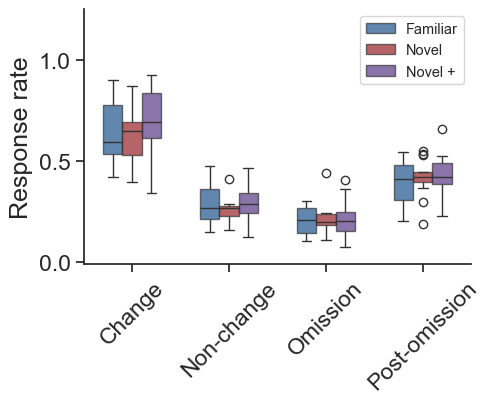

In [43]:
ppf.plot_response_rate_by_trial_type(response_rate_df, metric='response_rate', fraction_engaged_thresh=0.5,
                                     ylabel='Response rate', ylims=(-0.01, 1),
                                     save_dir=save_dir, folder='behavior_metrics', ax=None)


## Composite figure

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3087: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['%d-%d' % (int(b), int(b) + bin_size_minutes) for b in bin_order])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:7985: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(t)[:1].upper() + str(t)[1:] for t in trial_types], rotation=45)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2457: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2457: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


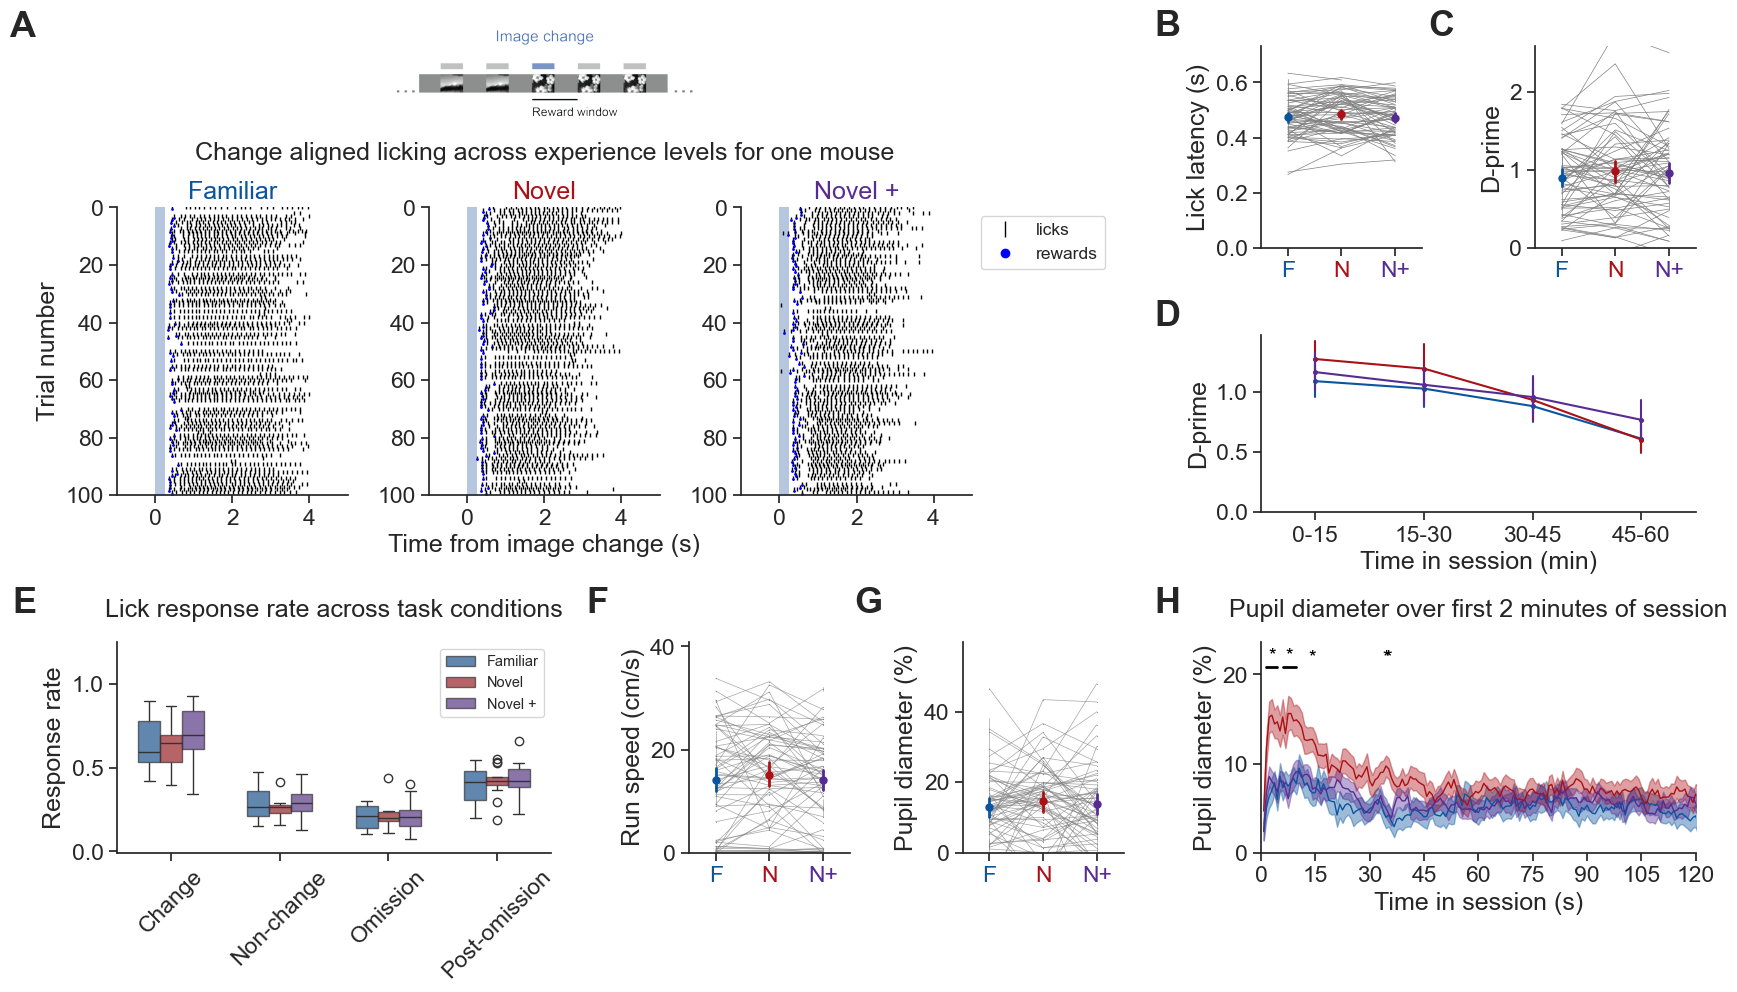

In [49]:
# Composite Figure 2 (stimulus-based)
#   A  lick rasters
#   B  lick latency      C  mean d-prime          (top row, right block)
#   D  rolling d-prime over time in session       (right block)
#   E  response rate by trial type
#   F  run speed         G  pupil diameter  (by experience)
#   H  pupil diameter over first 2 min of session
# Requires the stim-based prep cell above plus familiar/novel/novel_plus_dataset and the running/pupil mdfs.

colors = utils.get_experience_level_colors()
figsize = (28, 10)
fig = plt.figure(figsize=figsize)
# per-panel over-time stats are written to a dedicated stats folder (one CSV per metric,
# named <metric>_over_time_experience_stats_<test>.csv) rather than the combined stats csv,
# since they are per-time-bin rather than per-experience/mouse.
stats_dir = os.path.join(save_dir, 'composite', 'figure_2_stats') if save_dir else None

def panel_label(ax, label, dx=-58, dy=16):
    ax.annotate(label, xy=(0, 1), xycoords='axes fraction',
                xytext=(dx, dy), textcoords='offset points',
                fontsize=28, fontweight='bold', va='bottom', ha='right',
                annotation_clip=False)

# ---- Panel A: lick rasters F / N / N+ ----
ax_A = utils.placeAxesOnGrid(fig, dim=[1, 3], xspan=[0.06, 0.58], yspan=[0.21, 0.55], wspace=0.35)
for i, (dataset, label) in enumerate(zip(
        [familiar_dataset, novel_dataset, novel_plus_dataset], ['Familiar', 'Novel', 'Novel +'])):
    trials = dataset.trials.copy()
    trials = trials[trials.go == True][:100]
    ax_A[i] = ppf.plot_lick_raster_for_trials(trials, title=label, legend=(i == 2), ax=ax_A[i])
    ax_A[i].set_title(label, color=colors[i])
    ax_A[i].set_xlabel('')
    if i > 0:
        ax_A[i].set_ylabel('')
ax_A[1].set_xlabel('Time from image change (s)')

# image-change schematic banner above the lick rasters (preserve aspect ratio; banner is
# ~3.3:1 so size the axes box to match and center it over panel A)
schematic_path = os.path.join(loading.get_platform_analysis_cache_dir(),
                              'schematics', 'Figure 1', 'image_change.png')
ax_A_sch = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.225, 0.415], yspan=[0.0, 0.11])
ax_A_sch.imshow(plt.imread(schematic_path))
ax_A_sch.axis('off')
# panel-A section title: between the image-change schematic and the lick rasters,
# centered on the middle (Novel) raster column so it tracks the actual axes position
_pA = ax_A[1].get_position()
fig.text(0.5 * (_pA.x0 + _pA.x1), 1 - 0.165,
         'Change aligned licking across experience levels for one mouse',
         ha='center', va='center', fontsize=plt.rcParams['axes.titlesize'])
panel_label(ax_A[0], 'A', dy=118)

# ---- Panels B / C: top row of the right-hand block (unchanged content) ----
ax_BC = utils.placeAxesOnGrid(fig, dim=[1, 2], xspan=[0.74, 1.0], yspan=[0.02, 0.26], wspace=0.7)
ax_B, ax_C = ax_BC[0], ax_BC[1]

# B: full-session mean lick latency (stim-based)
ppf.plot_behavior_metric_by_experience(
    stim_stats.copy(), 'lick_latency', title='', ylabel='Lick latency (s)', ylims=None,
    show_mice=True, plot_stats=True, stripplot=False, show_ns=False, stats_dir=stats_dir, ax=ax_B)
panel_label(ax_B, 'B', dy=2)

# C: full-session mean d-prime (stim-based)
ppf.plot_behavior_metric_by_experience(
    stim_stats.copy(), 'mean_dprime', title='', ylabel='D-prime', ylims=(0, 2.3),
    show_mice=True, plot_stats=True, stripplot=False, show_ns=False, stats_dir=stats_dir, ax=ax_C)
panel_label(ax_C, 'C', dy=2)

# ---- Panel D: rolling d-prime over time in session (fills the old D/E space) ----
ax_D = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.74, 1.0], yspan=[0.36, 0.58])
ppf.plot_metric_in_time_bins_by_experience(
    rolling_mouse, metric='rolling_dprime', bin_size_minutes=15, max_minutes=60,
    plot_type='pointplot', ylabel='D-prime',
    add_stats=True, plot_ns=False, stats_dir=stats_dir, ax=ax_D)
if ax_D.get_legend() is not None:
    ax_D.get_legend().remove()
panel_label(ax_D, 'D', dy=2)

# ---- Bottom row ----
# E: response rate by trial type
ax_E = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.06, 0.32], yspan=[0.72, 0.97])
ppf.plot_response_rate_by_trial_type(
    response_rate_df, metric='response_rate', fraction_engaged_thresh=0.5,
    ylabel='Response rate', ylims=(-0.01, 1), ax=ax_E)
ax_E.set_title('Lick response rate across task conditions', pad=18)
panel_label(ax_E, 'E')

# F / G: run speed and pupil diameter by experience (split the old panel-G space)
ax_FG = utils.placeAxesOnGrid(fig, dim=[1, 2], xspan=[0.40, 0.66], yspan=[0.72, 0.97], wspace=0.7)
ax_F, ax_G = ax_FG[0], ax_FG[1]

df = running_speed_mdf_changes.copy(); df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(
    df, 'mean_response', 'changes', 'running_speed', ylabel='Run speed (cm/s)',
    ylims=None, show_mice=True, pointplot=True, stripplot=False, horiz=False, title='', stats_dir=stats_dir, ax=ax_F)
panel_label(ax_F, 'F')

df = pupil_mdf_changes.copy(); df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(
    df, 'mean_response', 'changes', 'pupil_width', ylabel='Pupil diameter (%)',
    ylims=None, show_mice=True, pointplot=True, stripplot=False, horiz=False, title='', stats_dir=stats_dir, ax=ax_G)
panel_label(ax_G, 'G')

# H: pupil diameter over first 2 min of session
ax_H = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.74, 1.0], yspan=[0.72, 0.97])
ppf.plot_metric_across_stimuli_by_experience_level(
    image_sdf, 'mean_pupil_width', time_window_min=2, title='',
    ylabel='Pupil diameter (%)', ylim=(0, 20), interval=20,
    add_stats=True, plot_ns=False, stats_dir=stats_dir, ax=ax_H)
ax_H.set_xlabel('Time in session (s)')
ax_H.set_title('Pupil diameter over first 2 minutes of session', pad=18)
panel_label(ax_H, 'H')

utils.save_figure(fig, figsize, save_dir, 'composite', 'figure_2_composite', formats=['.png', '.pdf'])
